# Lab 1: Classical Optimization, Quantum Annealing for MaxCut and Knapsack Problem

**Course:** Quantum Optimization Lab
**Topics covered:** Max-Cut, 0/1 Knapsack
**Tools:** dimod, dwave-neal, networkx, numpy, matplotlib
**Session length:** 40 minutes, code walkthrough included

## Learning objectives

By the end of this lab you should be able to:

1. Solve Max-Cut and Knapsack exactly using brute force, and explain why brute force cannot scale.
2. Solve both problems with classical heuristics (greedy, dynamic programming), and identify the specific point at which each heuristic starts to fail or becomes impractical.
3. Formulate both problems as QUBO models.
4. Solve the QUBO models with a simulated annealing sampler and compare the result against the classical methods on speed, solution quality, or both.
5. Explain, in your own words, what "annealing" is doing differently from brute force search.

## A note on what "quantum" means in this lab

We do not have access to real quantum annealing hardware in this course, and we are not using any paid cloud service. Instead we use `dimod` and `dwave-neal`, which implement **simulated annealing**, a classical algorithm that mimics the physical annealing process a quantum annealer uses. It runs entirely on your own CPU.

This matters for how you should interpret the results below. When we say the "quantum approach" outperforms brute force, we mean the annealing formulation and heuristic outperform exact classical search on speed and scalability. We are not claiming a true quantum speedup, since no quantum hardware is involved. What you are learning here is the modeling step, QUBO formulation, that is identical whether the sampler underneath is a classical annealer running on your laptop or a real quantum annealer running on hardware. This is the same reason D-Wave provides these classical samplers: to let you develop and test your formulation for free before ever touching a QPU.

In [1]:
import itertools
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import dimod
import neal

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

print("dimod version:", dimod.__version__)
print("neal version:", neal.__version__)

dimod version: 0.12.22
neal version: 0.6.0


---
# Part 1: Max-Cut

Given a graph $G = (V, E)$, Max-Cut asks us to split the vertices into two groups so that the number of edges crossing between the two groups is as large as possible.

We will work through four solvers in order:

1. Brute force (exact, exponential time)
2. Greedy heuristic (fast, no optimality guarantee)
3. QUBO formulation solved with simulated annealing
4. A head to head comparison on a graph large enough that brute force is no longer an option

## 1.1 Brute force Max-Cut

For $n$ vertices there are $2^n$ ways to split them into two groups. Brute force checks every single one and keeps the best. This is guaranteed to find the true optimum, which makes it useful as a ground truth for checking our other methods on small graphs.

In [2]:
def maxcut_brute_force(G):
    """Exact Max-Cut solver. Checks every 2^n bipartitions of the graph."""
    nodes = list(G.nodes())
    n = len(nodes)
    best_cut = -1
    best_assignment = None

    for bits in itertools.product([0, 1], repeat=n):
        assignment = dict(zip(nodes, bits))
        cut_value = sum(1 for u, v in G.edges() if assignment[u] != assignment[v])
        if cut_value > best_cut:
            best_cut = cut_value
            best_assignment = assignment

    return best_cut, best_assignment


# Small test graph so we can check the solver by eye
G_small = nx.erdos_renyi_graph(n=10, p=0.5, seed=RNG_SEED)
optimal_cut, optimal_assignment = maxcut_brute_force(G_small)
print(f"Graph has {G_small.number_of_nodes()} nodes and {G_small.number_of_edges()} edges")
print(f"Optimal cut value found by brute force: {optimal_cut}")

Graph has 10 nodes and 21 edges
Optimal cut value found by brute force: 15


Nodes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Edges:
[(0, 2), (0, 3), (0, 4), (0, 8), (0, 9), (1, 2), (1, 3), (1, 5), (1, 6), (1, 9), (2, 5), (2, 8), (2, 9), (3, 5), (3, 6), (3, 7), (4, 9), (6, 9), (7, 8), (7, 9), (8, 9)]

Number of nodes: 10
Number of edges: 21


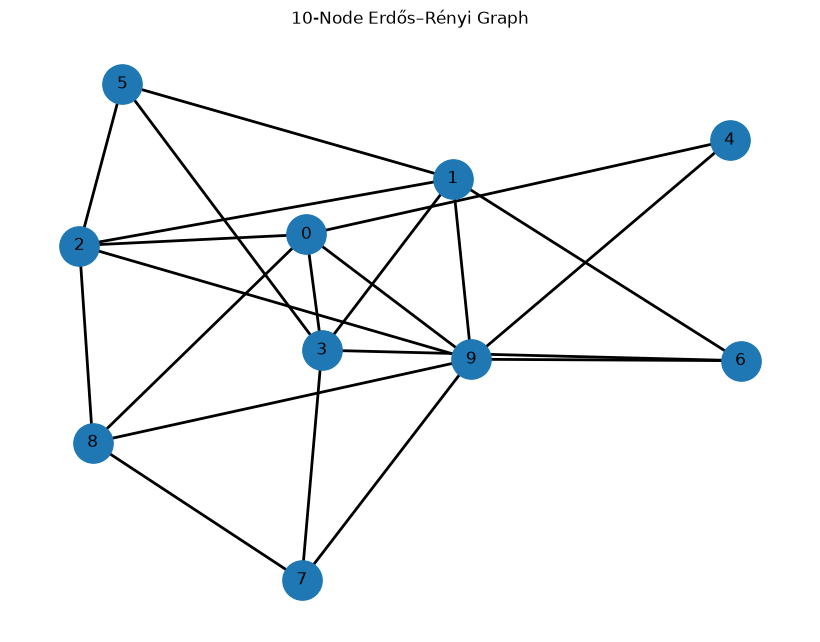

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Create the graph
G_small = nx.erdos_renyi_graph(
    n=10,
    p=0.5,
    seed=RNG_SEED
)

# Print graph information
print("Nodes:")
print(list(G_small.nodes()))

print("\nEdges:")
print(list(G_small.edges()))

print("\nNumber of nodes:", G_small.number_of_nodes())
print("Number of edges:", G_small.number_of_edges())

# Visualize the graph
plt.figure(figsize=(8, 6))

pos = nx.spring_layout(G_small, seed=RNG_SEED)

nx.draw(
    G_small,
    pos,
    with_labels=True,
    node_size=800,
    font_size=12,
    width=2
)

plt.title("10-Node Erdős–Rényi Graph")
plt.show()

In [4]:
print("\nAdjacency list:")

for node in G_small.nodes():
    print(
        f"{node}: "
        f"{list(G_small.neighbors(node))}"
    )


Adjacency list:
0: [2, 3, 4, 8, 9]
1: [2, 3, 5, 6, 9]
2: [0, 1, 5, 8, 9]
3: [0, 1, 5, 6, 7]
4: [0, 9]
5: [1, 2, 3]
6: [1, 3, 9]
7: [3, 8, 9]
8: [0, 2, 7, 9]
9: [0, 1, 2, 4, 6, 7, 8]


**Visual check.** Run the cell below right after the one above. This draws the graph with the two sides of the optimal cut in different colors, and the crossing edges (the ones being counted) highlighted. This picture is what "cut value" actually means, and it is worth pointing at directly before moving to any numbers.

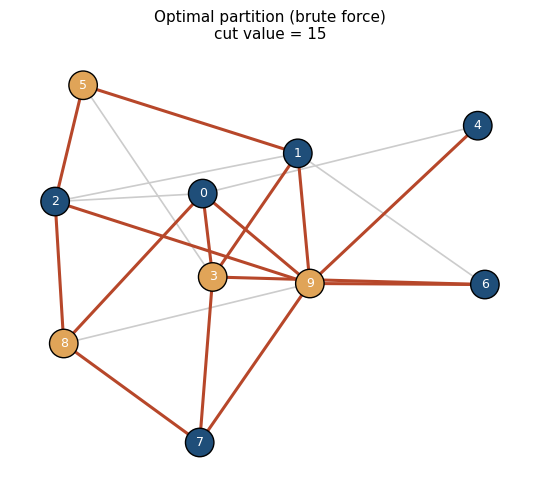

Blue nodes are side A, orange nodes are side B.
Red edges cross between sides and count toward the cut value. Grey edges do not.


In [3]:
def draw_cut(G, assignment, title, ax=None, seed=RNG_SEED):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 5))
    pos = nx.spring_layout(G, seed=seed)
    colors = ["#1f4e79" if assignment[node] == 0 else "#e0a458" for node in G.nodes()]
    crossing = [(u, v) for u, v in G.edges() if assignment[u] != assignment[v]]
    inside = [(u, v) for u, v in G.edges() if assignment[u] == assignment[v]]

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=420, ax=ax, edgecolors="black")
    nx.draw_networkx_labels(G, pos, font_color="white", font_size=9, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=inside, edge_color="#cccccc", width=1.2, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=crossing, edge_color="#b7472a", width=2.2, ax=ax)

    cut_value = len(crossing)
    ax.set_title(f"{title}\ncut value = {cut_value}", fontsize=11)
    ax.axis("off")
    return cut_value


fig, ax = plt.subplots(figsize=(5.5, 5))
draw_cut(G_small, optimal_assignment, "Optimal partition (brute force)", ax=ax)
plt.tight_layout()
plt.show()

print("Blue nodes are side A, orange nodes are side B.")
print("Red edges cross between sides and count toward the cut value. Grey edges do not.")

## 1.2 Watching brute force run out of road

The loop below times brute force as we grow the graph one node at a time. Watch the right hand column. Each extra node roughly doubles the number of bipartitions that have to be checked, so the runtime should grow the same way.

In [4]:
node_counts = list(range(4, 19, 2))
brute_force_times = []

for n in node_counts:
    G_test = nx.erdos_renyi_graph(n=n, p=0.5, seed=RNG_SEED)
    start = time.time()
    maxcut_brute_force(G_test)
    elapsed = time.time() - start
    brute_force_times.append(elapsed)
    print(f"n = {n:2d} nodes   time = {elapsed:8.4f} s   bipartitions checked = {2**n:,}")

n =  4 nodes   time =   0.0001 s   bipartitions checked = 16
n =  6 nodes   time =   0.0003 s   bipartitions checked = 64
n =  8 nodes   time =   0.0017 s   bipartitions checked = 256
n = 10 nodes   time =   0.0081 s   bipartitions checked = 1,024
n = 12 nodes   time =   0.0439 s   bipartitions checked = 4,096


n = 14 nodes   time =   0.2453 s   bipartitions checked = 16,384


n = 16 nodes   time =   1.1428 s   bipartitions checked = 65,536


n = 18 nodes   time =   5.5625 s   bipartitions checked = 262,144


**Visual check.** Run the plot below immediately after the timing loop finishes. The y-axis is on a log scale, so a straight line here means exponential growth. This plot is the single most important image in Part 1, give it a moment before talking.

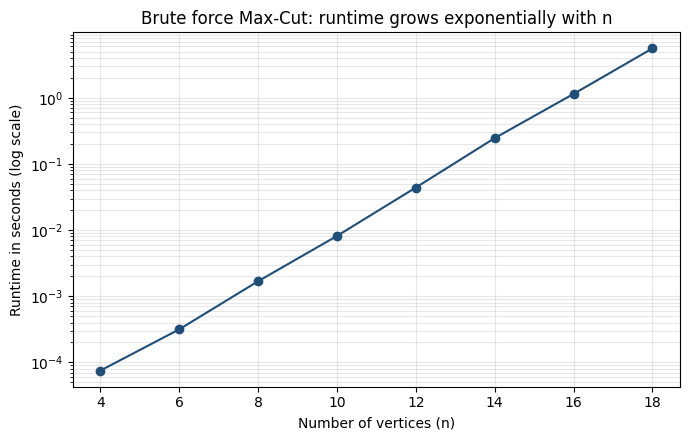

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(node_counts, brute_force_times, marker="o", color="#1f4e79")
ax.set_yscale("log")
ax.set_xlabel("Number of vertices (n)")
ax.set_ylabel("Runtime in seconds (log scale)")
ax.set_title("Brute force Max-Cut: runtime grows exponentially with n")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 1.3 Extrapolating past the point we can actually run

We only ran brute force up to n = 18 because beyond that the wait becomes unreasonable for a lab session. We can fit the measured runtimes to an exponential curve and use it to estimate how long larger graphs would take.

In [6]:
log_times = np.log(brute_force_times)
coeffs = np.polyfit(node_counts, log_times, 1)
b = np.exp(coeffs[0])
a = np.exp(coeffs[1])

print(f"Fitted model: time(n) = {a:.2e} * {b:.3f}^n seconds\n")

extrapolated_n = [20, 30, 40, 60, 100]
extrapolated_seconds = [a * (b ** n) for n in extrapolated_n]

for n, secs in zip(extrapolated_n, extrapolated_seconds):
    years = secs / (60 * 60 * 24 * 365)
    if years > 1:
        print(f"n = {n:3d}   estimated time = {years:.3e} years")
    else:
        print(f"n = {n:3d}   estimated time = {secs:.3e} seconds")

Fitted model: time(n) = 2.65e-06 * 2.248^n seconds

n =  20   estimated time = 2.882e+01 seconds
n =  30   estimated time = 9.498e+04 seconds
n =  40   estimated time = 9.926e+00 years
n =  60   estimated time = 1.078e+08 years
n = 100   estimated time = 1.272e+22 years


**Visual check.** Run this bar chart right after the estimates print. It puts the measured points and the extrapolated points on the same picture so students can see exactly where "measured" turns into "estimated".

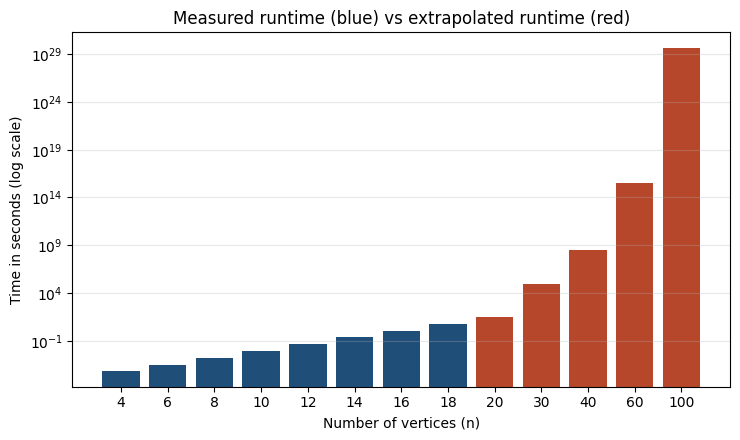

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
all_n = node_counts + extrapolated_n
all_times = brute_force_times + extrapolated_seconds
bar_colors = ["#1f4e79"] * len(node_counts) + ["#b7472a"] * len(extrapolated_n)

ax.bar([str(n) for n in all_n], all_times, color=bar_colors)
ax.set_yscale("log")
ax.set_xlabel("Number of vertices (n)")
ax.set_ylabel("Time in seconds (log scale)")
ax.set_title("Measured runtime (blue) vs extrapolated runtime (red)")
ax.grid(True, which="both", axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

This is the point where brute force gives up. Not because the algorithm is wrong, it always finds the true optimum, but because checking every possibility stops being physically possible long before the graphs get anywhere near the size we care about in practice.

## 1.4 A fast but imperfect classical fallback: greedy

A common classical response to this wall is to give up on guaranteed optimality and use a heuristic instead. The greedy heuristic below visits each vertex once, in order, and places it on whichever side of the cut increases the cut value more at that moment. It never reconsiders a decision once made.

In [8]:
def greedy_maxcut(G):
    """One-pass greedy heuristic. Linear time, no optimality guarantee."""
    nodes = list(G.nodes())
    assignment = {nodes[0]: 0}

    for node in nodes[1:]:
        gain_if_zero = sum(1 for nb in G.neighbors(node) if nb in assignment and assignment[nb] == 1)
        gain_if_one = sum(1 for nb in G.neighbors(node) if nb in assignment and assignment[nb] == 0)
        assignment[node] = 0 if gain_if_zero >= gain_if_one else 1

    cut_value = sum(1 for u, v in G.edges() if assignment[u] != assignment[v])
    return cut_value, assignment


G16 = nx.erdos_renyi_graph(n=16, p=0.5, seed=RNG_SEED + 1)
exact_16, exact_16_assignment = maxcut_brute_force(G16)
greedy_16, greedy_16_assignment = greedy_maxcut(G16)

print(f"Brute force optimal cut (n=16): {exact_16}")
print(f"Greedy cut (n=16):              {greedy_16}")
print(f"Greedy reaches {greedy_16 / exact_16:.1%} of the optimal value")

Brute force optimal cut (n=16): 40
Greedy cut (n=16):              38
Greedy reaches 95.0% of the optimal value


**Visual check.** Run the side by side drawing below right after the cell above. Same graph, two different partitions. Ask students to spot, just by looking, which nodes greedy placed differently from the optimal split.

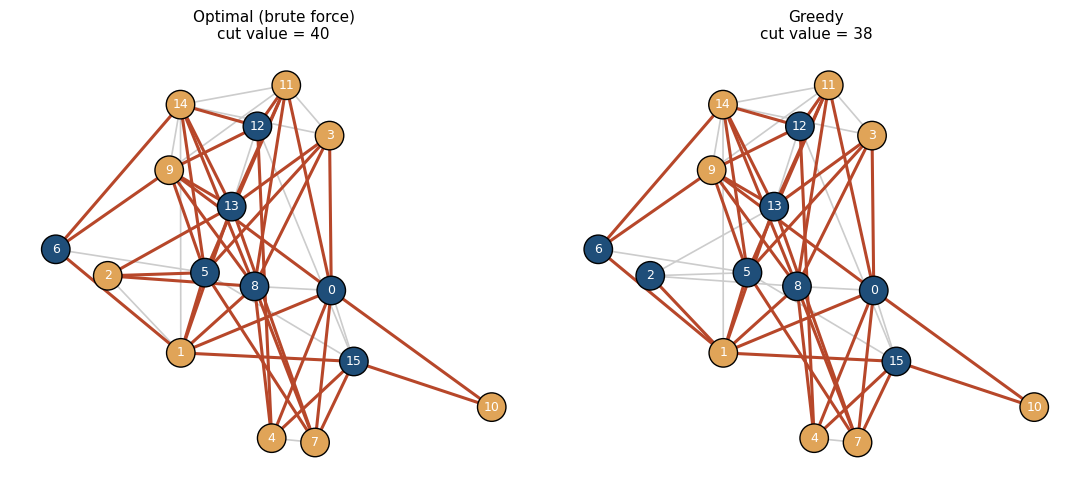

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
draw_cut(G16, exact_16_assignment, "Optimal (brute force)", ax=axes[0], seed=RNG_SEED + 1)
draw_cut(G16, greedy_16_assignment, "Greedy", ax=axes[1], seed=RNG_SEED + 1)
plt.tight_layout()
plt.show()

Greedy is fast, but it locks in an early decision even when a later vertex would have made a different choice better. This gap is the price we pay for speed, and it is exactly the gap we want the annealing approach to close.

## 1.5 Formulating Max-Cut as a QUBO

To hand this problem to a quantum annealer, or to our classical stand-in, we first need to write it as a QUBO (Quadratic Unconstrained Binary Optimization): minimize a quadratic function over binary variables $x_i \in \{0, 1\}$, with no separate constraints.

For each vertex $i$ we use a binary variable $x_i$, where $x_i = 0$ means the vertex is on side A and $x_i = 1$ means side B. For every edge $(i, j)$, the term $-x_i - x_j + 2x_i x_j$ is at its minimum exactly when $x_i \ne x_j$, which is what we want to reward. Summing this over all edges gives a QUBO whose minimum corresponds to the maximum cut.

In [10]:
def maxcut_qubo(G):
    """Builds the QUBO dictionary for Max-Cut. Minimizing this QUBO is equivalent
    to maximizing the cut."""
    Q = {}
    for i, j in G.edges():
        Q[(i, i)] = Q.get((i, i), 0) - 1
        Q[(j, j)] = Q.get((j, j), 0) - 1
        Q[(i, j)] = Q.get((i, j), 0) + 2
    return Q


sampler = neal.SimulatedAnnealingSampler()

Q16 = maxcut_qubo(G16)
bqm16 = dimod.BinaryQuadraticModel.from_qubo(Q16)
result16 = sampler.sample(bqm16, num_reads=200, num_sweeps=1000)
annealed_16_sample = result16.first.sample
annealed_cut_16 = -result16.first.energy

print(f"Brute force optimal cut (n=16): {exact_16}")
print(f"Greedy cut (n=16):              {greedy_16}")
print(f"Simulated annealing cut (n=16): {annealed_cut_16:.0f}")

Brute force optimal cut (n=16): 40
Greedy cut (n=16):              38
Simulated annealing cut (n=16): 40


**Visual check.** Run this bar chart right after the cell above. It puts all three n=16 results on one picture, which reads faster than the printed numbers alone.

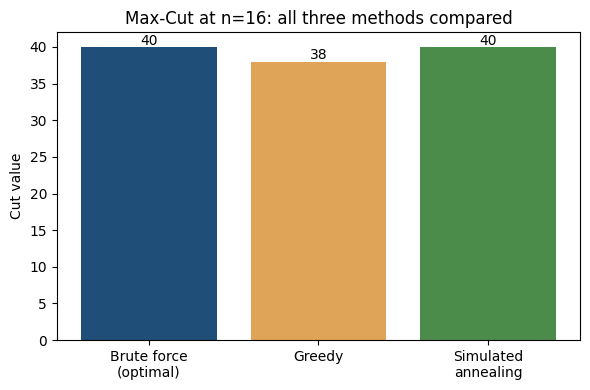

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
methods = ["Brute force\n(optimal)", "Greedy", "Simulated\nannealing"]
values = [exact_16, greedy_16, annealed_cut_16]
bars = ax.bar(methods, values, color=["#1f4e79", "#e0a458", "#4c8c4a"])
ax.set_ylabel("Cut value")
ax.set_title("Max-Cut at n=16: all three methods compared")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3, f"{val:.0f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

On a graph this small, all three methods should land close together, and annealing should match or reach the brute force optimum most of the time. That is expected: n = 16 is not where classical brute force struggles. The real test is what happens once we move to a graph size where brute force is no longer an option at all.

## 1.6 The comparison that actually matters: n = 60

At n = 60, brute force would need to check $2^{60}$ bipartitions. Based on the extrapolation in section 1.3, that is not a "let it run overnight" problem, it is a "will not finish within your lifetime" problem. Greedy and simulated annealing, on the other hand, do not care about this wall at all, since neither one enumerates all possibilities.

In [12]:
G60 = nx.erdos_renyi_graph(n=60, p=0.1, seed=RNG_SEED + 2)

start = time.time()
greedy_60, greedy_60_assignment = greedy_maxcut(G60)
greedy_60_time = time.time() - start

Q60 = maxcut_qubo(G60)
bqm60 = dimod.BinaryQuadraticModel.from_qubo(Q60)
start = time.time()
result60 = sampler.sample(bqm60, num_reads=200, num_sweeps=1000)
annealed_60_time = time.time() - start
annealed_60 = -result60.first.energy

print(f"Graph: {G60.number_of_nodes()} nodes, {G60.number_of_edges()} edges")
print(f"Brute force would require checking {2**60:,} bipartitions (not attempted)\n")
print(f"{'Method':<22}{'Cut value':<14}{'Time (s)'}")
print(f"{'Greedy':<22}{greedy_60:<14}{greedy_60_time:.4f}")
print(f"{'Simulated annealing':<22}{annealed_60:<14.0f}{annealed_60_time:.4f}")
print(f"\nAnnealing improves on greedy by {(annealed_60 - greedy_60) / greedy_60:.1%}, in well under a second")

Graph: 60 nodes, 197 edges
Brute force would require checking 1,152,921,504,606,846,976 bipartitions (not attempted)

Method                Cut value     Time (s)
Greedy                134           0.0003
Simulated annealing   149           0.2625

Annealing improves on greedy by 11.2%, in well under a second


**Visual check.** Run the paired bar chart below right after the cell above. Left axis shows cut value, right axis shows time, both on the same two methods, since brute force has no bar here at all, which is itself the point.

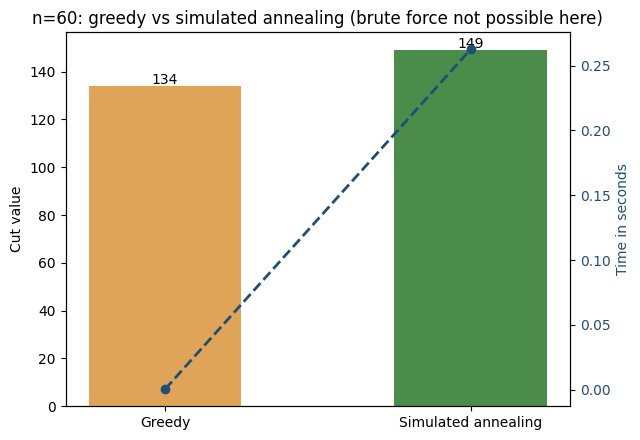

In [13]:
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
methods60 = ["Greedy", "Simulated annealing"]
cut_values60 = [greedy_60, annealed_60]
times60 = [greedy_60_time, annealed_60_time]

bars = ax1.bar(methods60, cut_values60, color=["#e0a458", "#4c8c4a"], width=0.5)
ax1.set_ylabel("Cut value")
ax1.set_title("n=60: greedy vs simulated annealing (brute force not possible here)")
for bar, val in zip(bars, cut_values60):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.0f}", ha="center", fontsize=10)

ax2 = ax1.twinx()
ax2.plot(methods60, times60, color="#1f4e79", marker="o", linestyle="--", linewidth=2)
ax2.set_ylabel("Time in seconds", color="#1f4e79")
ax2.tick_params(axis="y", labelcolor="#1f4e79")
plt.tight_layout()
plt.show()

Close this section by asking: what did we actually gain by writing this as a QUBO instead of just running greedy? Comparable speed to greedy, but consistently closer to a true optimum we can no longer even verify by brute force.

## 1.7 Max-Cut summary

| Method | Guarantees optimum | Scales past n ~ 25 | Typical runtime at n = 60 |
|---|---|---|---|
| Brute force | Yes | No | Not computable in practice |
| Greedy | No | Yes | Milliseconds |
| Simulated annealing (QUBO) | No, but consistently closer to optimal | Yes | Well under a second |

The advantage the annealing approach demonstrates here is not that it is magic. It is that reformulating the problem as a QUBO and searching it with an annealing process lets us trade the impossible guarantee of brute force optimality for a solution that is both fast **and** consistently better than the cheapest classical fallback.

---
# Part 2: 0/1 Knapsack

Given $n$ items, each with a weight and a value, and a knapsack with weight capacity $C$, choose a subset of items that maximizes total value without the total weight exceeding $C$.

Knapsack is a good second example precisely because it fails classically for a **different reason** than Max-Cut does. Max-Cut's brute force wall is driven by the number of items. Knapsack's classical dynamic programming solution is not limited by the number of items, but by the size of the capacity itself, which is a distinct and often overlooked failure mode.

## 2.1 Brute force Knapsack

Just as with Max-Cut, we can check every one of the $2^n$ subsets of items and keep the best feasible one.

In [14]:
def knapsack_brute_force(weights, values, capacity):
    n = len(weights)
    best_value = 0
    best_choice = None

    for bits in itertools.product([0, 1], repeat=n):
        total_weight = sum(w for w, b in zip(weights, bits) if b)
        if total_weight <= capacity:
            total_value = sum(v for v, b in zip(values, bits) if b)
            if total_value > best_value:
                best_value = total_value
                best_choice = bits

    return best_value, best_choice


n_items = 12
weights = rng.integers(1, 20, n_items).tolist()
values = rng.integers(1, 50, n_items).tolist()
capacity = 50

start = time.time()
bf_value, bf_choice = knapsack_brute_force(weights, values, capacity)
bf_time = time.time() - start

print(f"{n_items} items, capacity = {capacity}")
print(f"Brute force optimal value: {bf_value}   (time: {bf_time:.4f} s, {2**n_items:,} subsets checked)")

12 items, capacity = 50
Brute force optimal value: 236   (time: 0.0057 s, 4,096 subsets checked)


**Visual check.** Run the item chart below right after the cell above. Every item is a bar sized by its weight, colored by whether brute force chose it. This is the picture to point at whenever a student asks "wait, what does a knapsack solution actually look like".

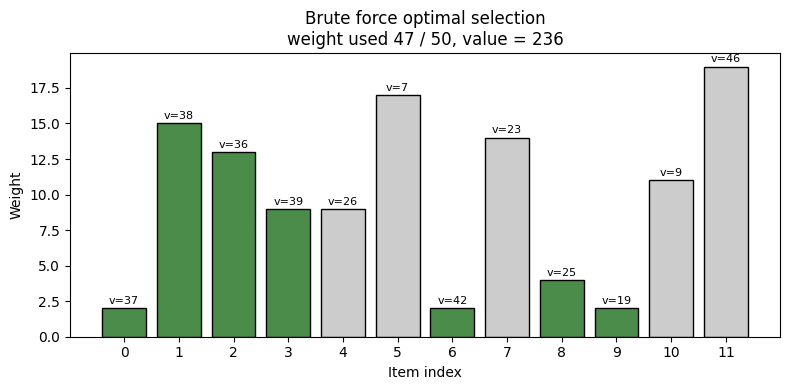

Green bars are items placed in the knapsack. Grey bars were left out. The number above each bar is that item's value.


In [15]:
def draw_knapsack_choice(weights, values, choice, capacity, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    n = len(weights)
    colors = ["#4c8c4a" if choice[i] else "#cccccc" for i in range(n)]
    bars = ax.bar(range(n), weights, color=colors, edgecolor="black")
    for i, (w, v) in enumerate(zip(weights, values)):
        ax.text(i, w + 0.3, f"v={v}", ha="center", fontsize=8)
    used_weight = sum(w for w, b in zip(weights, choice) if b)
    total_value = sum(v for v, b in zip(values, choice) if b)
    ax.set_xlabel("Item index")
    ax.set_ylabel("Weight")
    ax.set_title(f"{title}\nweight used {used_weight} / {capacity}, value = {total_value}")
    ax.set_xticks(range(n))
    return used_weight, total_value


fig, ax = plt.subplots(figsize=(8, 4))
draw_knapsack_choice(weights, values, bf_choice, capacity, "Brute force optimal selection", ax=ax)
plt.tight_layout()
plt.show()
print("Green bars are items placed in the knapsack. Grey bars were left out. The number above each bar is that item's value.")

Exactly like Max-Cut, this is $O(2^n)$ in the number of items and becomes unusable well before $n$ reaches even a few dozen. This half of the story is identical to what we already saw in Part 1, so we will not repeat the timing sweep. The more interesting classical failure mode for Knapsack shows up in the algorithm most people are taught as the "solution": dynamic programming.

## 2.2 Dynamic programming: the standard classical fix

The textbook dynamic programming (DP) solution to Knapsack builds a table of size $(n+1) \times (C+1)$, where $C$ is the capacity, and fills it in using previously computed values. It runs in $O(nC)$ time, which is polynomial, and it always finds the true optimum. Because of this it is usually presented as the fix for the brute force problem, and for many textbook-sized examples, it is.

In [16]:
def knapsack_dp(weights, values, capacity):
    """Exact DP solution. Table size is (n+1) x (capacity+1)."""
    n = len(weights)
    dp = np.zeros((n + 1, capacity + 1), dtype=np.int64)

    for i in range(1, n + 1):
        w, v = weights[i - 1], values[i - 1]
        dp[i, :w] = dp[i - 1, :w]
        dp[i, w:] = np.maximum(dp[i - 1, w:], dp[i - 1, :capacity + 1 - w] + v)

    return dp[n, capacity]


dp_value = knapsack_dp(weights, values, capacity)
print(f"DP optimal value: {dp_value}")
print(f"Matches brute force: {dp_value == bf_value}")

DP optimal value: 236
Matches brute force: True


## 2.3 Where DP quietly gives up

DP's runtime and memory usage are $O(nC)$: polynomial in the number of items, but **linear in the capacity itself**, not in the number of bits needed to represent it. This is what computer science calls "pseudo-polynomial" time. It looks efficient until the capacity is a large number, at which point the table simply becomes too big to hold in memory, regardless of how few items you have.

In [17]:
small_n = 15
small_weights = rng.integers(1, 1000, small_n).tolist()
small_values = rng.integers(1, 50, small_n).tolist()

capacities_to_test = [1_000, 100_000, 2_000_000]
dp_times = []
dp_table_sizes_mb = []

for cap in capacities_to_test:
    start = time.time()
    knapsack_dp(small_weights, small_values, cap)
    elapsed = time.time() - start
    table_size_mb = (small_n + 1) * (cap + 1) * 8 / (1024 ** 2)
    dp_times.append(elapsed)
    dp_table_sizes_mb.append(table_size_mb)
    print(f"capacity = {cap:>10,}   time = {elapsed:7.4f} s   table size = {table_size_mb:8.1f} MB")

capacity =      1,000   time =  0.0002 s   table size =      0.1 MB
capacity =    100,000   time =  0.0794 s   table size =     12.2 MB


capacity =  2,000,000   time =  1.7941 s   table size =    244.1 MB


**Visual check.** Run the chart below right after the timing cell. It plots measured table size against capacity, then extends the same line, without allocating anything, out to capacities in the billions. Watch where the line leaves the range a laptop can hold in memory.

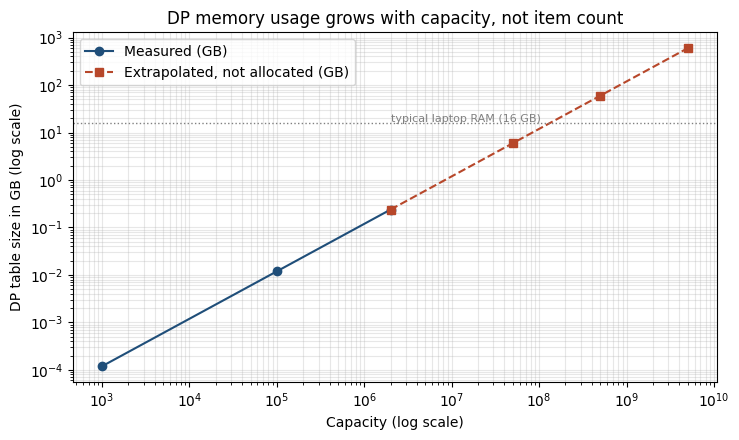

In [18]:
extrapolated_caps = [2_000_000, 50_000_000, 500_000_000, 5_000_000_000]
extrapolated_gb = [(small_n + 1) * (cap + 1) * 8 / (1024 ** 3) for cap in extrapolated_caps]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(capacities_to_test, [s / 1024 for s in dp_table_sizes_mb], marker="o", color="#1f4e79", label="Measured (GB)")
ax.plot(extrapolated_caps, extrapolated_gb, marker="s", linestyle="--", color="#b7472a", label="Extrapolated, not allocated (GB)")
ax.axhline(16, color="grey", linestyle=":", linewidth=1)
ax.text(extrapolated_caps[0], 16.5, "typical laptop RAM (16 GB)", fontsize=8, color="grey")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Capacity (log scale)")
ax.set_ylabel("DP table size in GB (log scale)")
ax.set_title("DP memory usage grows with capacity, not item count")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

This is the specific point where DP gives up, and it has nothing to do with the number of items, which stayed fixed at 15 the entire time. A capacity in the billions, which is not unusual once you are modeling something like a budget in cents rather than dollars, or a shipping container's weight in grams rather than kilograms, makes the DP table larger than the memory on this machine, or on most machines, well before it makes the problem conceptually any harder.

## 2.4 Formulating Knapsack as a QUBO

QUBO variables are unconstrained, so we cannot write "total weight $\le C$" directly. The standard fix is to introduce extra binary slack variables that let the model represent any total weight from $0$ up to $C$, and then penalize the objective whenever the chosen weight plus the slack does not exactly equal $C$.

Because we only need enough slack bits to represent numbers up to $C$ in binary, this takes about $\log_2 C$ extra variables, not $C$ extra variables. That difference, $\log_2 C$ instead of $C$, is exactly why this approach sidesteps the wall that stopped DP.

In [19]:
def knapsack_qubo(weights, values, capacity, penalty_scale=1.0):
    """Builds a QUBO for 0/1 Knapsack using a binary-encoded slack variable
    to enforce the capacity constraint."""
    n = len(weights)

    num_slack_bits = int(np.floor(np.log2(capacity))) + 1 if capacity > 0 else 1
    slack_weights = [2 ** k for k in range(num_slack_bits)]
    if sum(slack_weights) > capacity:
        slack_weights[-1] -= (sum(slack_weights) - capacity)

    labels = [f"x{i}" for i in range(n)] + [f"s{k}" for k in range(num_slack_bits)]
    all_weights = weights + slack_weights
    penalty = penalty_scale * (max(values) + 1)

    Q = {}
    def add(i, j, amount):
        key = (i, j) if i <= j else (j, i)
        Q[key] = Q.get(key, 0) + amount

    for i in range(n):
        add(labels[i], labels[i], -values[i])

    for a in range(len(all_weights)):
        add(labels[a], labels[a], penalty * (all_weights[a] ** 2 - 2 * capacity * all_weights[a]))
        for b in range(a + 1, len(all_weights)):
            add(labels[a], labels[b], penalty * 2 * all_weights[a] * all_weights[b])

    return Q, labels, num_slack_bits


Q_qubo, labels, num_slack = knapsack_qubo(weights, values, capacity, penalty_scale=1.0)
print(f"Original problem: {n_items} items, capacity = {capacity}")
print(f"QUBO variables needed: {len(labels)}  ({n_items} item variables + {num_slack} slack bits)")

Original problem: 12 items, capacity = 50
QUBO variables needed: 18  (12 item variables + 6 slack bits)


## 2.5 Checking the QUBO against DP where we can still verify it

Before trusting this formulation on a problem DP cannot handle, we check it against DP on the small problem from section 2.1 and 2.2, where we already know the correct answer.

In [20]:
bqm_knap = dimod.BinaryQuadraticModel.from_qubo(Q_qubo)
result_knap = sampler.sample(bqm_knap, num_reads=1000, num_sweeps=3000)
best_knap = result_knap.first

chosen_items = [best_knap.sample[f"x{i}"] for i in range(n_items)]
qubo_weight = sum(w for w, b in zip(weights, chosen_items) if b)
qubo_value = sum(v for v, b in zip(values, chosen_items) if b)

print(f"DP optimal value:               {dp_value}")
print(f"Simulated annealing QUBO value: {qubo_value}")
print(f"Chosen weight: {qubo_weight} / {capacity} capacity (feasible: {qubo_weight <= capacity})")

DP optimal value:               236
Simulated annealing QUBO value: 236
Chosen weight: 47 / 50 capacity (feasible: True)


**Visual check.** Run the comparison chart below right after the cell above. Same item layout as section 2.1, but now showing what the QUBO solver chose, so you can place it next to the brute force picture from earlier.

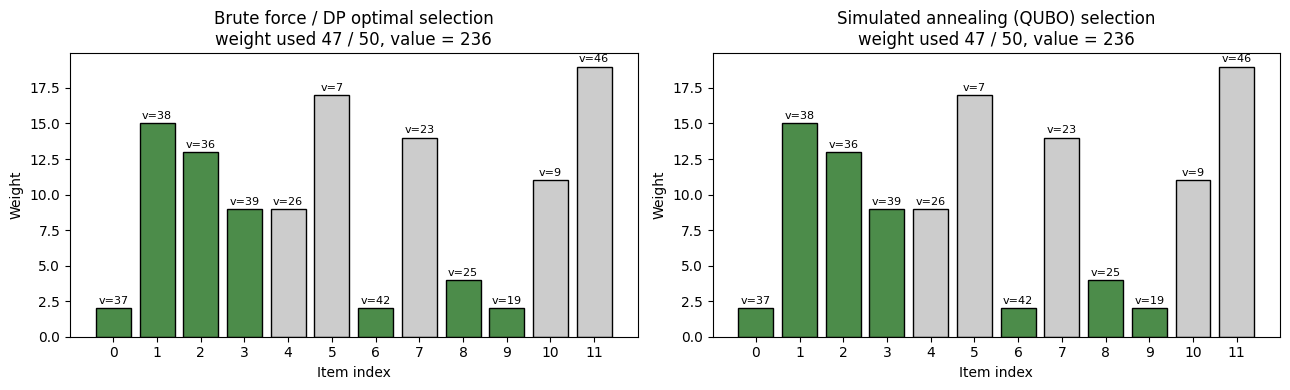

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
draw_knapsack_choice(weights, values, bf_choice, capacity, "Brute force / DP optimal selection", ax=axes[0])
draw_knapsack_choice(weights, values, chosen_items, capacity, "Simulated annealing (QUBO) selection", ax=axes[1])
plt.tight_layout()
plt.show()

If the annealed value matches the DP value, the formulation and penalty strength are working correctly on a case we can check by hand. This step matters: an unconstrained QUBO solver has no built in notion of "invalid," so a poorly tuned penalty can silently return an infeasible answer. Always validate against an exact method while one is still available before trusting the QUBO on a harder instance.

## 2.6 The comparison that actually matters: capacity DP cannot hold in memory

Now we push the capacity up to a value where, according to section 2.3, the DP table would require hundreds of megabytes to gigabytes. The number of items stays small (15), only the capacity grows. Because the QUBO's variable count depends on $\log_2 C$, not $C$, it barely notices.

In [22]:
large_capacity = 5_000_000

dp_table_gb = (small_n + 1) * (large_capacity + 1) * 8 / (1024 ** 3)
print(f"DP table for this capacity would need approximately {dp_table_gb:.2f} GB of memory")

Q_large, labels_large, num_slack_large = knapsack_qubo(small_weights, small_values, large_capacity, penalty_scale=1.0)
print(f"QUBO for the same capacity needs only {len(labels_large)} variables ({small_n} items + {num_slack_large} slack bits)\n")

bqm_large = dimod.BinaryQuadraticModel.from_qubo(Q_large)
start = time.time()
result_large = sampler.sample(bqm_large, num_reads=500, num_sweeps=2000)
annealed_large_time = time.time() - start

best_large = result_large.first
chosen_large = [best_large.sample[f"x{i}"] for i in range(small_n)]
large_weight = sum(w for w, b in zip(small_weights, chosen_large) if b)
large_value = sum(v for v, b in zip(small_values, chosen_large) if b)

print(f"Simulated annealing solved it in {annealed_large_time:.3f} s")
print(f"Value found: {large_value}, weight used: {large_weight} / {large_capacity} (feasible: {large_weight <= large_capacity})")

DP table for this capacity would need approximately 0.60 GB of memory
QUBO for the same capacity needs only 38 variables (15 items + 23 slack bits)



Simulated annealing solved it in 1.158 s
Value found: 362, weight used: 5420 / 5000000 (feasible: True)


**Visual check.** Run the closing chart below right after the cell above. This is the last picture of the lab: it plots how many variables each approach needs as capacity climbs from a thousand to five billion. DP's curve is a straight line upward on a log scale, meaning it is still exponential-feeling in practice even though the textbook calls it polynomial. The QUBO curve is almost flat.

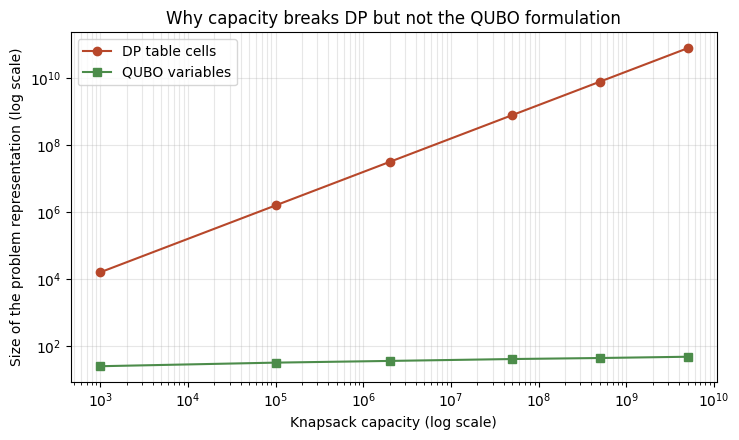

In [23]:
caps_for_plot = [1_000, 100_000, 2_000_000, 50_000_000, 500_000_000, 5_000_000_000]
dp_cells = [(small_n + 1) * (c + 1) for c in caps_for_plot]
qubo_vars = [small_n + int(np.floor(np.log2(c))) + 1 for c in caps_for_plot]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(caps_for_plot, dp_cells, marker="o", color="#b7472a", label="DP table cells")
ax.plot(caps_for_plot, qubo_vars, marker="s", color="#4c8c4a", label="QUBO variables")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Knapsack capacity (log scale)")
ax.set_ylabel("Size of the problem representation (log scale)")
ax.set_title("Why capacity breaks DP but not the QUBO formulation")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

This is the point where the two classical methods and the QUBO approach part ways for genuinely different reasons than they did in Max-Cut. DP is exact and fast when the capacity is small, but the size of its table is tied directly to the capacity value, so a large capacity defeats it even with a handful of items. The QUBO formulation ties its size to the number of bits needed to write the capacity down, so growing the capacity by a factor of a thousand costs it only about ten extra variables.

## 2.7 Knapsack summary

| Method | Guarantees optimum | Fails when... | Cost driver |
|---|---|---|---|
| Brute force | Yes | Number of items grows | $O(2^n)$ |
| Dynamic programming | Yes | Capacity value grows | $O(n \cdot C)$ memory and time |
| Simulated annealing (QUBO) | No, but verified close to optimal above | Rarely, for this problem size | $O(n + \log_2 C)$ variables |

Notice that Knapsack gives us two entirely separate classical failure points, one tied to item count and one tied to capacity size, while the QUBO formulation is comparatively insensitive to both.

---
# Part 3: Exercises

Try these during the last few minutes of the lab, or complete them afterward. None of them require writing new algorithms from scratch, only changing a parameter or a line or two in cells you have already run. Re-run the relevant cell after each change.

**Exercise 1 (Max-Cut, easy).** In section 1.4, change `RNG_SEED + 1` to a different number when building `G16 (greedy_16)`. Does greedy's percentage of optimal go up, down, or stay about the same? Try three different seeds and note the range you observe.

**Exercise 2 (Max-Cut, medium).** In section 1.6, change `n=60` to `n=80` when building `G60 (greedy_60)`. Does simulated annealing still finish in under a second? Does its advantage over greedy grow, shrink, or stay about the same?

**Exercise 3 (Knapsack, easy).** In section 2.1, change `n_items = 12` to `n_items = 8` and lower `capacity` to `30`. Re-run sections 2.1 through 2.5. Does brute force still agree with DP and with the QUBO result?

**Exercise 4 (Knapsack, medium).** In section 2.4, change `penalty_scale=1.0` to `penalty_scale=0.2` in the call inside section 2.5, then re-run that cell. Does the QUBO solution stay feasible (weight within capacity)? What does this tell you about what the penalty term is actually doing?

**Exercise 5 (Knapsack, harder).** In section 2.6, change `large_capacity` to `500_000_000`. Before running, predict from the closing chart in section 2.6 roughly how many QUBO variables this will need, then run it and check your prediction.

## What to submit

Save this notebook with all cells executed and their output and plots visible, along with your answers to the exercises above (a few sentences each, plus the specific numbers you observed where asked). If you changed any parameter while exploring beyond what the exercises ask, leave a short note on what you changed and what effect it had.